### ANSWER
Learning objectives assessed:

* Use curve_fit to fit a model to data
* Assess the goodness of a fit to data
* Explore the effect of different parameters on a system modeled by ODEs with solve_ivp
* Create visualizations that follow best-practices


### Instructor guide:

The primary goal of this quiz is to assess students' knowledge of fitting models to data, exploring systems that can be modeled with ODEs (using solve_ivp), and creating clear visualizations. Because of the duration of the quiz (30-40 minutes), asking students to develop a solve_ivp code from start to finish (i.e. equations to visualized results) is unreasonable. Therefore, you should choose just one part to focus on (i.e. converting a comaprtmental model to equations, converting equations to a derivative functions, using solve_ivp to run a model, exploring effects of parameters on a model). The most effective way to assess solve_ivp understanding I have found is to have students adjust parameters for working code, but depending on what you emphasized in class, you may want to use a different portion.

For curve_fit, the primary lift should be fitting a model and judging if the fit is any good. Tehrefore, it would be better to provide data to fit rather than having them load it in. The bootcamps and homework should be what you base your quiz questions on!

**Part 1**

* **Question 1 (20 points):** Given data, use curve_fit to fit it with a model (give a model, have them write the code)
* **Question 2 (20 points):** Visualize the data and the model, determine if the fit is good

**Part 2**

* **Question 4 (20 points):** Given a derivs function for a model, run solve_ivp for a set of conditions and visualize
* **Question 5 (20 points):** Change 1-2 parameters and visualize, record observations
* **Question 6 (10 points):** Record observations of the changed parameters

The example below is one possible implementation of this structure, but I can provide additional examples if you aren't sure what to do!

## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (Section XXX - Fall 2022) TEMPLATE

The goal of this quiz is to give you the opportunity to test out some of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your new programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

---
# Academic integrity statement [10 points]

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---

# Part 1: Finding a Ukulele Pitch

You recently took up playing ukulele, and you want to start building an app that can help you tune your strings. That's a pretty big job, but you think if you can fit the sound data, you might be able to get some information about the frequency!

---

#### &#9989;&nbsp; **Question 1 (20 points):** Using the data and provided model below, use `curve_fit` to find best fit parameters for *a, b,* and *c*. Print out your results.

In [1]:
# reading in the the data
import pandas as pd
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

ukulele_data = pd.read_json('{"time": [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 40.5, 41.0, 41.5, 42.0, 42.5, 43.0, 43.5, 44.0, 44.5, 45.0, 45.5, 46.0, 46.5, 47.0, 47.5, 48.0, 48.5, 49.0, 49.5, 50.0, 50.5, 51.0, 51.5, 52.0, 52.5, 53.0, 53.5, 54.0, 54.5, 55.0, 55.5, 56.0, 56.5, 57.0, 57.5, 58.0, 58.5, 59.0, 59.5, 60.0, 60.5, 61.0, 61.5, 62.0, 62.5, 63.0, 63.5, 64.0, 64.5, 65.0, 65.5, 66.0, 66.5, 67.0, 67.5, 68.0, 68.5, 69.0, 69.5],\
"volts":[0.03329885739261618, 1.3843617851659276, 2.626780106826555, 3.1900098975045017, 3.83575513448105, 3.5926125370284474, 3.8012789477794637, 2.786011865462603, 2.447519690422597, 2.1382260421485855, 1.2639789327860498, -0.4155770275014745, -0.6537344418294663, -1.622223823902767, -2.3965606010155076, -2.5168496897799617, -2.4566267766210204, -2.4287214112027016, -1.9817456503722677, -0.8141144504003559, -0.18753051227693873, 0.5553804503062286, 1.8151308581370935, 2.351398762065781, 2.8975596894096007, 3.337220623354716, 3.6361105958814592, 3.1877181485229746, 3.3829057940729363, 2.5927364167099727, 1.4464503983008292, 0.8184532593521192, -0.7928901850889102, -0.9110091431678811, -1.5480176889068202, -2.314134171922991, -2.8446943333135004, -2.7206780735253817, -2.06866410561157, -1.7008466279232386, -0.32005961945246253, 0.6499453140138496, 1.70404510050089, 1.6125898301053323, 3.286455462848129, 3.697440884739572, 3.7223607873337414, 3.4751260178407524, 3.2166350464233924, 2.9329326713862995, 2.038875478397883, 0.6675717025929461, 0.21177309976158393, -1.1872386076533012, -1.7240949728514359, -1.7512180502343708, -2.3628222378351906, -2.5731261056350467, -2.32379248777808, -2.206010180874973, -1.4831891517200972, -0.7054819228308938, 0.4876166811138322, 1.3518943929602298, 2.5056502626671815, 3.457637534520105, 3.0733325415418973, 3.923219424992631, 3.0925650183398052, 3.473293634328379, 2.5113054365227248, 1.1894505698700142, 0.7334743622165764, -0.6765355520236304, -1.1741940148827934, -1.6051222537551202, -2.411113623575618, -2.1578307368947236, -2.116922473640601, -2.3066231353117645, -1.574619690505247, -1.0329334297964254, -0.20252160485862042, 1.289413434098257, 2.092960063907406, 3.085407529726121, 3.151553042198736, 3.6514209634759034, 3.2262414651447613, 3.4126953176340464, 2.6878873782738064, 2.056792058162569, 1.0719589078558038, 0.749882286930255, -0.47155419175558133, -1.7631340026434175, -1.6207238998687594, -2.119854218701821, -2.456269185167976, -2.4807275737955803, -2.4343321089273964, -1.6802991388127906, -0.15161796262649274, 0.14533099754120476, 1.4323929149061163, 1.8394608453238281, 2.5086984062458186, 3.4981845303851977, 3.918346913884617, 3.945337400699214, 3.5864161545245903, 2.4040986268891724, 1.88658465709391, 0.5447126949800389, -0.1396040248374395, -1.2266631480744994, -1.7081550155117637, -2.3107754819339577, -2.088596875530177, -2.123690541884724, -2.1440083656155724, -1.4029355309947475, -1.328165843551351, 0.14899665415276353, 1.029475390908698, 2.075396045655122, 2.9717903708835745, 3.4025907883210555, 3.6414174309048395, 3.563543086230881, 2.996584773800657, 2.4805295212011247, 2.214059265188566, 1.8125875829819407, 0.4062543873168812, -0.1048401273952504, -1.3206189790001628, -1.5854860231220813, -2.831362695948938, -2.7988203077446308] }')
ukulele_data.head()

,time,volts
0,0.0,0.033299
1,0.5,1.384362
2,1.0,2.626780
3,1.5,3.190010
4,2.0,3.835755


In [2]:
# defining the model

def sine_wave(t,a,b,c):
    return a*np.sin(b*t)+c

In [3]:
# put your curve_fit code here!

In [4]:
### ANSWER ###

def sine_wave(t,a,b,c):
    return a*np.sin(b*t)+c


params,ignore = curve_fit(sine_wave,ukulele_data['time'],ukulele_data['volts'],p0=[2,0.65,1])
print(params)

[3.11107621 0.60961388 0.5392182 ]


#### &#9989;&nbsp; **Question 2 (20 points):** Plot your data and best fit. Then, using any *quantitative* method of determining how good a fit is (feel free to pull directly from homework, classwork, or bootcamps), calculate the goodness of fit. 

In [5]:
# put your code here

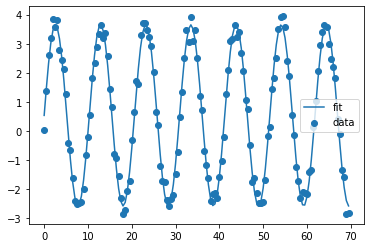

In [6]:
### ANSWER ###
plt.scatter(ukulele_data['time'],ukulele_data['volts'],label='data')
plt.plot(ukulele_data['time'],sine_wave(ukulele_data['time'],params[0],params[1],params[2]),label='fit')
plt.legend()

In [7]:
### ANSWER ###
# using MSE (any method is fine though)
def MSE(data, fit):
    return np.sum((data - fit) ** 2) / len(data)
print(MSE(sine_wave(ukulele_data['time'],params[0],params[1],params[2]),ukulele_data['volts']))

0.08280065485473383


---

# Part 2: Modeling A Squid's Brain Activity

---
<div align="center"><img src="https://payload.cargocollective.com/1/7/243906/11957379/Eldar-Zakirov-2016--Seaside-Oceanarium--Seaside-Oceanarium--SquidoGianto_1500.jpg" width=500px></div>

---

In 1952, Hodgkin and Huxley devised a mathematical model for brain activity in a giant squid by applying electrical impulses to a squid's brain and recording the resulting acitivity. They described the activation of a neuron in the squid's brain in terms of the interaction between an activator and an inhibitor, now simplified into the *FitzHugh-Nagumo equations* given below:


$$ \frac{dv}{dt} = v - \frac{1}{3}v - w + I $$

$$ \frac{dw}{dt} = 0.08(v-0.8w+0.7) $$

In these equations, $v$ represents the electric potential across the membrane of a squid neuron, $w$ represents the current due to the movement of ions across the membrane of the neuron, and $I$ represents a current applied to the neuron in the experiment. The variables $v$ and $w$ change with time, while $I$ is a constant.

You are a marine biologist, and you have been asked to create a working synthetic squid brain model for the local children's museum. Your model needs to show brain activity for the values of $I$ observed in experiments on live giant squids, but you've lost the documentation for those $I$ values and need to use the FitzHugh-Nagumo equations to reverse-engineer them.

---

#### &#9989;&nbsp; **Question 4 (20 points):** Luckily, you have some notes on reasonable values of $I$, and you know that $I$ is somewhere between 0.1 and 2. Using the derivatives function provided, initial values for $v$ and $w$ below, and the code to run the model, find one value of $I$ that results in brain activity. Example plots of activity and no activity are given below.

* Your initial value for v is 0.7 at time t=0 (i.e. v(0)=0.7)
* Your initial value for w is 0 at time t=0 (i.e. w(0)=0)
* An appropriate value of $I$ is somewhere between 0.1 and 2

<div align="center"><img src="https://github.com/msu-cmse-courses/cmse201-S22-data/blob/730ed8b1c680300a3323c5a403351dce8a44f5fe/brain_actvity.png?raw=true" width=550px></div>

<div align="center"><img src="https://github.com/msu-cmse-courses/cmse201-S22-data/blob/730ed8b1c680300a3323c5a403351dce8a44f5fe/no_actvity.png?raw=true" width=550px></div>

In [8]:
# derivatives function
from scipy.integrate import solve_ivp

def derivs(t,curr_vals,I):
    v = curr_vals[0]
    w = curr_vals[1]
    dvdt = v-(v**3)/3-w+I
    dwdt = 0.08*(v-0.8*w+0.7)
    return dvdt,dwdt

In [9]:
# solve_ivp code to run the model

v0 = 0.7
w0 = 0

init = [v0,w0]

I = ??

tmax = 500
dt = 1
time = np.arange(0, tmax + dt, dt)

sol = solve_ivp(derivs,(0,500),init,t_eval=time,args=[I])

fig = plt.figure(figsize=(10,8))
plt.plot(sol.t,sol.y[0],label='v(t)')
plt.plot(sol.t,sol.y[1],label='w(t)')
plt.xlabel('Time [s]')
plt.ylabel('Current')
plt.legend()

SyntaxError: invalid syntax (Temp/ipykernel_22616/1746502929.py, line 8)

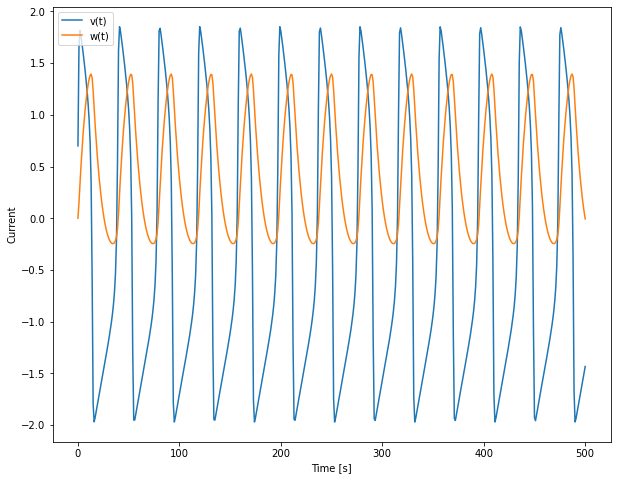

In [11]:
### ANSWER ###


v0 = 0.7
w0 = 0

init = [v0,w0]

I = 0.5

tmax = 500
dt = 1
time = np.arange(0, tmax + dt, dt)

sol = solve_ivp(derivs,(0,500),init,t_eval=time,args=[I])

fig = plt.figure(figsize=(10,8))
plt.plot(sol.t,sol.y[0],label='v(t)')
plt.plot(sol.t,sol.y[1],label='w(t)')
plt.xlabel('Time [s]')
plt.ylabel('Current')
plt.legend()

#### &#9989;&nbsp; **Question 5 (20 points):** Now that you have identified one value of $I$ that results in brain acitivity, you want to take your model one step further. Using the code from Question 4, identify either the minimum or maximum value of $I$ that result in brain activity.

In [12]:
# write your code here

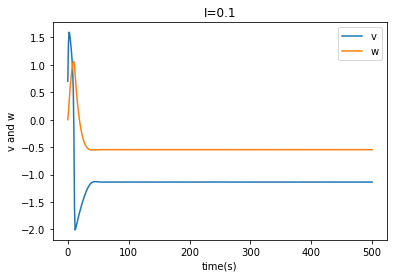

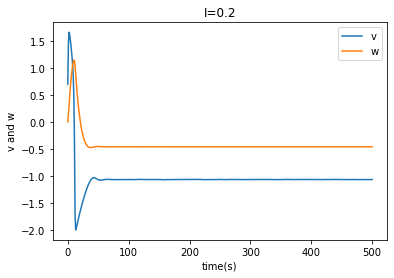

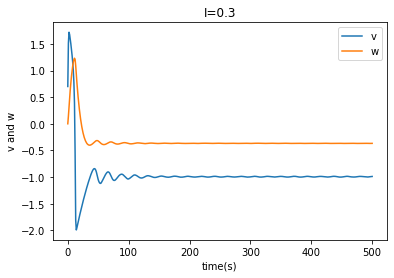

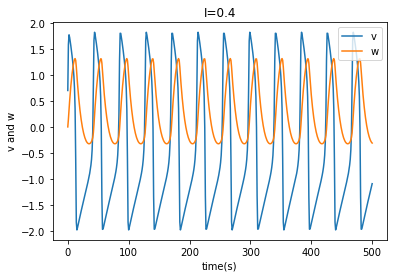

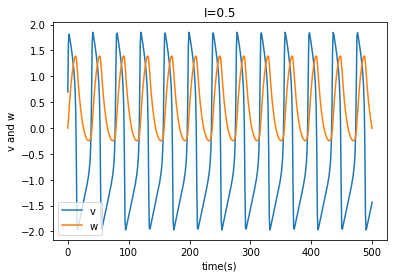

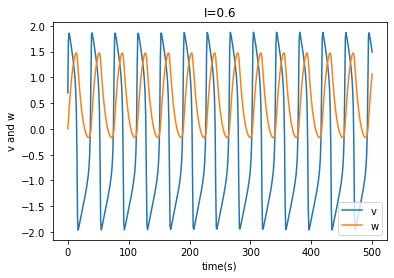

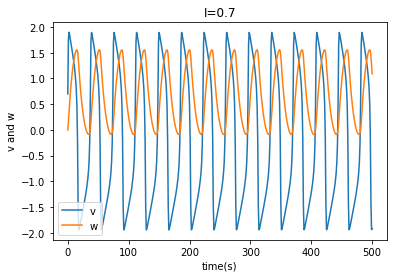

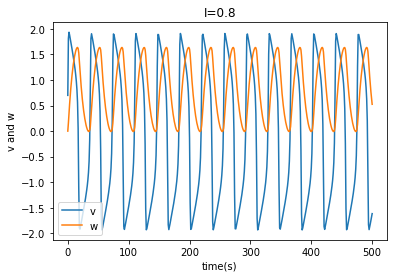

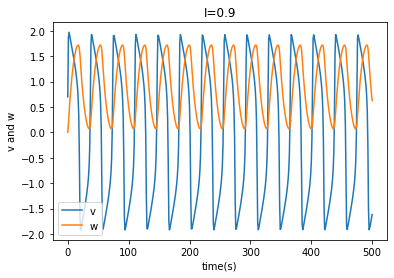

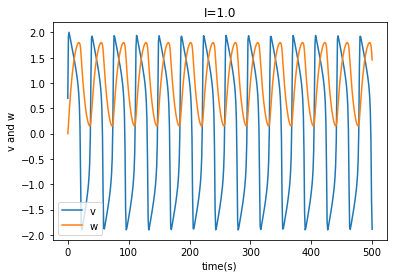

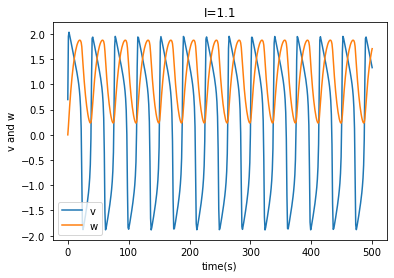

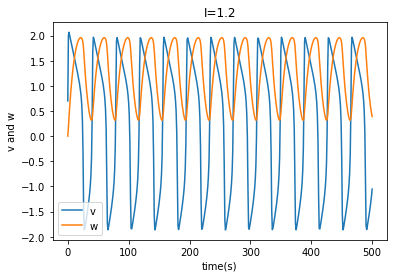

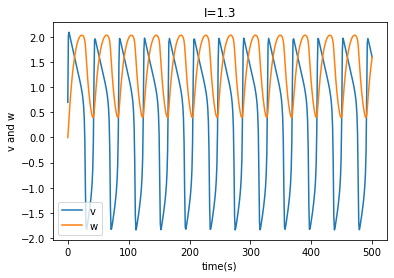

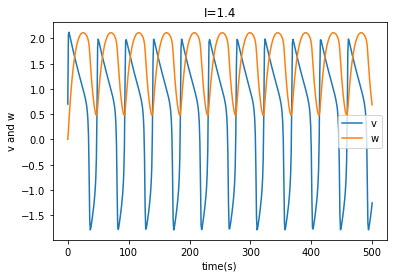

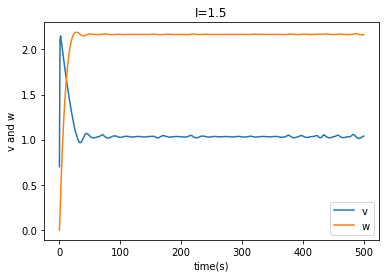

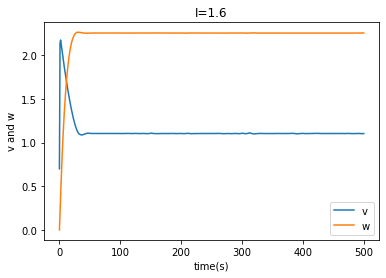

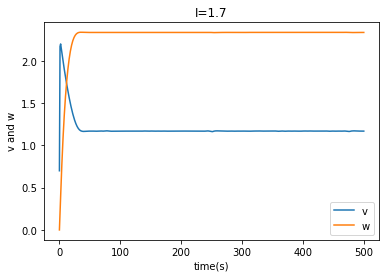

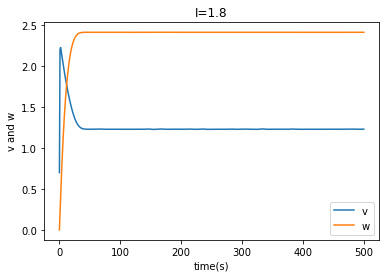

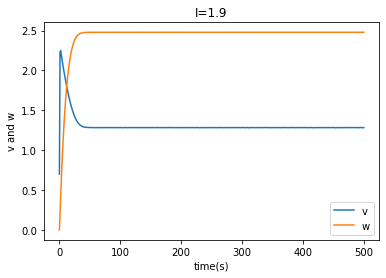

In [13]:
### ANSWER ###

I_list = np.arange(0.1,2,0.1)
for i in I_list:  
    I = i
    curr_vals = [0.7,0]
    sol = solve_ivp(derivs,(0,500),curr_vals,t_eval=time,args=[I])
    plt.plot(time,sol.y[0,:],label = 'v')
    plt.plot(time,sol.y[1,:], label='w')
    plt.ylabel('v and w')
    plt.xlabel('time(s)')
    plt.legend()
    plt.title('I='+str(np.round(I,3)))
    #plt.title('No Brain Activity')
    #plt.savefig('no_actvity.png')
    plt.show()
    plt.close()
    
# minimum is 0.4, maximum is 1.4

#### &#9989;&nbsp; **Question 6 [10 points]:  Write at least two observations about the effect of changing $I$ on $v$ and $w$ based on your work in Question 4 and 5. If you did not complete Question 4 and 5, Write a detailed explanation of what you tried and where you got stuck to get credit for this question.**

*Write your response here*

---

### Congratulations, you're done!

Submit this quiz by uploading it to the course Desire2Learn web page.  Go to the "Quizzes" section, find the submission folder link for Quiz #4, and upload it there.

In [ ]:
### ANSWER ###
#generating data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

time = np.arange(0,14*5,0.5)
#a_data = 2.5+np.random.random()
#b_data = 0.6+np.random.random()/50
volts = list((a_data)*np.sin(b_data*time)+np.random.random(len(time)))
plt.plot(time,volts)
plt.scatter(time,volts)
plt.grid()
#print(volts)
#print(list(time))

# making a json
uku_data ='{"time": [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0, 19.5, 20.0, 20.5, 21.0, 21.5, 22.0, 22.5, 23.0, 23.5, 24.0, 24.5, 25.0, 25.5, 26.0, 26.5, 27.0, 27.5, 28.0, 28.5, 29.0, 29.5, 30.0, 30.5, 31.0, 31.5, 32.0, 32.5, 33.0, 33.5, 34.0, 34.5, 35.0, 35.5, 36.0, 36.5, 37.0, 37.5, 38.0, 38.5, 39.0, 39.5, 40.0, 40.5, 41.0, 41.5, 42.0, 42.5, 43.0, 43.5, 44.0, 44.5, 45.0, 45.5, 46.0, 46.5, 47.0, 47.5, 48.0, 48.5, 49.0, 49.5, 50.0, 50.5, 51.0, 51.5, 52.0, 52.5, 53.0, 53.5, 54.0, 54.5, 55.0, 55.5, 56.0, 56.5, 57.0, 57.5, 58.0, 58.5, 59.0, 59.5, 60.0, 60.5, 61.0, 61.5, 62.0, 62.5, 63.0, 63.5, 64.0, 64.5, 65.0, 65.5, 66.0, 66.5, 67.0, 67.5, 68.0, 68.5, 69.0, 69.5],\
"volts":[0.03329885739261618, 1.3843617851659276, 2.626780106826555, 3.1900098975045017, 3.83575513448105, 3.5926125370284474, 3.8012789477794637, 2.786011865462603, 2.447519690422597, 2.1382260421485855, 1.2639789327860498, -0.4155770275014745, -0.6537344418294663, -1.622223823902767, -2.3965606010155076, -2.5168496897799617, -2.4566267766210204, -2.4287214112027016, -1.9817456503722677, -0.8141144504003559, -0.18753051227693873, 0.5553804503062286, 1.8151308581370935, 2.351398762065781, 2.8975596894096007, 3.337220623354716, 3.6361105958814592, 3.1877181485229746, 3.3829057940729363, 2.5927364167099727, 1.4464503983008292, 0.8184532593521192, -0.7928901850889102, -0.9110091431678811, -1.5480176889068202, -2.314134171922991, -2.8446943333135004, -2.7206780735253817, -2.06866410561157, -1.7008466279232386, -0.32005961945246253, 0.6499453140138496, 1.70404510050089, 1.6125898301053323, 3.286455462848129, 3.697440884739572, 3.7223607873337414, 3.4751260178407524, 3.2166350464233924, 2.9329326713862995, 2.038875478397883, 0.6675717025929461, 0.21177309976158393, -1.1872386076533012, -1.7240949728514359, -1.7512180502343708, -2.3628222378351906, -2.5731261056350467, -2.32379248777808, -2.206010180874973, -1.4831891517200972, -0.7054819228308938, 0.4876166811138322, 1.3518943929602298, 2.5056502626671815, 3.457637534520105, 3.0733325415418973, 3.923219424992631, 3.0925650183398052, 3.473293634328379, 2.5113054365227248, 1.1894505698700142, 0.7334743622165764, -0.6765355520236304, -1.1741940148827934, -1.6051222537551202, -2.411113623575618, -2.1578307368947236, -2.116922473640601, -2.3066231353117645, -1.574619690505247, -1.0329334297964254, -0.20252160485862042, 1.289413434098257, 2.092960063907406, 3.085407529726121, 3.151553042198736, 3.6514209634759034, 3.2262414651447613, 3.4126953176340464, 2.6878873782738064, 2.056792058162569, 1.0719589078558038, 0.749882286930255, -0.47155419175558133, -1.7631340026434175, -1.6207238998687594, -2.119854218701821, -2.456269185167976, -2.4807275737955803, -2.4343321089273964, -1.6802991388127906, -0.15161796262649274, 0.14533099754120476, 1.4323929149061163, 1.8394608453238281, 2.5086984062458186, 3.4981845303851977, 3.918346913884617, 3.945337400699214, 3.5864161545245903, 2.4040986268891724, 1.88658465709391, 0.5447126949800389, -0.1396040248374395, -1.2266631480744994, -1.7081550155117637, -2.3107754819339577, -2.088596875530177, -2.123690541884724, -2.1440083656155724, -1.4029355309947475, -1.328165843551351, 0.14899665415276353, 1.029475390908698, 2.075396045655122, 2.9717903708835745, 3.4025907883210555, 3.6414174309048395, 3.563543086230881, 2.996584773800657, 2.4805295212011247, 2.214059265188566, 1.8125875829819407, 0.4062543873168812, -0.1048401273952504, -1.3206189790001628, -1.5854860231220813, -2.831362695948938, -2.7988203077446308] }'
print(a_data,b_data)

In [ ]:
### ANSWER ###
ukulele_data = pd.read_json(uku_data)
print(len(ukulele_data['time']),len(ukulele_data['volts']))
plt.plot(ukulele_data['time'],ukulele_data['volts'])